# FILTRO FROST

Nesse código foi feita a extração de funções utilities necessárias para o filtro frost contidas na biblioteca PyRadar (que não possuem open source), que atualmente está desatualizada.

O objetivo é obter o filtro frost independente da biblioteca.

**Inputs:**
- `wind_[modelo]_speed_smooth0.tif` - Velocidade do vento após inversão e filtragem

**Outputs:**
- `wind_[modelo]_speed_sooth0_frost.tif` - Resultado após filtragem frost



## 1. CONFIGURAÇÃO

In [20]:
import numpy as np
import rasterio
from scipy.stats import variation

WIND_SPEED_PATH = r"C:\Users\peric\Documents\sar2wind_daniel\FROST-FILTER-TEST\input\u10_xmod3.tif"

OUT_DIR = r"C:\Users\peric\Documents\sar2wind_daniel\FROST-FILTER-TEST\output"

COEF_VAR_DEFAULT = 0.01



## 2. UTILITIES

In [21]:
def assert_window_size(win_size):
    """
    Verifica se win_size é positivo e multiplo de 3.
    """
    assert win_size > 0, 'ERRO: win_size deve ser positivo.'
    assert win_size % 3 == 0, 'ERRO: win_size deve ser múltiplo de 3'

def assert_indices_in_range(width, height, xleft, xright, yup, ydown):
    assert 0 <= xleft and xright <= width and 0 <= yup and ydown <= height, 'ERRO: As dimensões da imagem não combinam'

def compute_coef_var(image, x_start, x_end, y_start, y_end):
    """
    Computa o coeficiente de variação na janela de [x_start: x_end] e
    [y_start:y_end] contida na imagem.
    """

    x_start, x_end, y_start, y_end = int(x_start), int(x_end), int(y_start), int(y_end)
    assert x_start >= 0, 'ERROR: x_start deve ser >= 0.'
    assert y_start >= 0, 'ERROR: y_start deve ser >= 0.'
    x_size, y_size = image.shape
    x_overflow = x_end > x_size
    y_overflow = y_end > y_size

    assert not x_overflow, 'ERROR: Parâmetros inválidos fizeram a janela de x transbordar.'
    assert not y_overflow, 'ERROR: Parâmetros inválidos fizeram a janela de y transbordar.'

    window = image[x_start:x_end, y_start:y_end]

    
    coef_var = variation(window, None)

    if not coef_var:
        coef_var = COEF_VAR_DEFAULT
    assert coef_var > 0, 'ERROR: Coeficiente de variação não pode ser zero.'

    return coef_var


def calculate_all_Mi(window_flat, factor_A, window):
    """
    Computa o peso de todos os pixels na janela
    """
    N, M = window.shape
    center_pixel = np.float64(window[int(N / 2), int(M / 2)])
    window_flat = np.float64(window_flat)

    distances = np.abs(window_flat - center_pixel)

    weights = np.exp(-factor_A * distances)

    return weights


def calculate_local_weight_matrix(window, factor_A):
    """
    Retorna uma array com o peso dos pixels em determinada janela.
    """
    weights_array = np.zeros(window.size)
    window_flat = window.flatten()

    weights_array = calculate_all_Mi(window_flat, factor_A, window)

    return weights_array

def apply_mask(img, mask):
    img_corrigida = img.copy()

    img_corrigida[mask != 0] = mask[mask != 0]

    return img_corrigida

def salvar_tif(array, arquivo_saida, arquivo_referencia):
    with rasterio.open(arquivo_referencia) as src:
        profile = src.profile.copy()

    profile.update(
        dtype=np.float32,
        count=1
    )

    with rasterio.open(arquivo_saida, 'w', **profile) as dst:
        dst.write(array.astype(np.float32), 1)

## 3. FILTRO E MÁSCARA

In [22]:
from scipy.stats import mode

def frost_filter(img, damping_factor=2.0, win_size=24):

    assert_window_size(win_size)

    img_filtered = np.zeros_like(img)
    N, M = img.shape
    win_offset = win_size / 2

    for i in range(0, N):
        xleft = i - win_offset
        xright = i + win_offset
        if xleft < 0:
            xleft = 0
        if xright >= N:
            xright = N - 1
        for j in range(0, M):
            yup = j - win_offset
            ydown = j + win_offset
            if yup < 0:
                yup = 0
            if ydown >= M:
                ydown = M - 1

            assert_indices_in_range(N, M, xleft, xright, yup, ydown)

            xleft, xright, yup, ydown = int(xleft), int(xright), int(yup), int(ydown)

            # inspired by http://www.pcigeomatics.com/cgi-bin/pcihlp/FFROST
            variation_coef = compute_coef_var(img, xleft, xright, yup, ydown)
            window = img[xleft:xright, yup:ydown]
            window_mean = window.mean()
            sigma_zero = variation_coef / window_mean  # var / u^2
            factor_A = damping_factor * sigma_zero

            weights_array = calculate_local_weight_matrix(window, factor_A)
            pixels_array = window.flatten()

            weighted_values = weights_array * pixels_array
            img_filtered[i, j] = weighted_values.sum() / weights_array.sum()

    return img_filtered

def platform_mask(img, win_size=12):

    assert_window_size(win_size)

    mask = np.zeros_like(img)
    N, M = img.shape
    win_offset = win_size // 2

    for i in range(0, N):
        xleft = i - win_offset
        xright = i + win_offset
        if xleft < 0:
            xleft = 0
        if xright >= N:
            xright = N - 1
        for j in range(0, M):
            yup = j - win_offset
            ydown = j + win_offset
            if yup < 0:
                yup = 0
            if ydown >= M:
                ydown = M - 1
            
            if img[i, j] <= 10:
                mask[i, j] = 0
            if img[i, j] >= 10:

                window = img[xleft:xright, yup:ydown]
                mask[i, j] = mode(window, axis=None, keepdims=False).mode
                """
                window_without_center = np.delete(
                    window.flatten(),
                    window.size // 2
                )

               window_mean = window_without_center.mean()
                """

    return mask

## 4. MAIN

In [ ]:

with rasterio.open(WIND_SPEED_PATH) as src:
    img = src.read(1).astype(np.float64)
    profile = src.profile.copy()
    h, w = src.height, src.width


wind_filtered = frost_filter(img)

mask = platform_mask(wind_filtered)

img_corrigida = apply_mask(img, mask)

out_profile = profile.copy()
out_profile.update(driver="GTiff", count=1, dtype="float32",
                   nodata=-9999.0, compress="deflate")

salvar_tif(
    wind_filtered,
    OUT_DIR + r"\u10_xmod3_frost.tif",
    img
)

salvar_tif(
    mask,
    OUT_DIR + r"\mask.tif",
    img
)

salvar_tif(
    img_corrigida,
    OUT_DIR + r"\wind_fixed.tif",
    img
)
    

## 5. COMPARAÇÃO

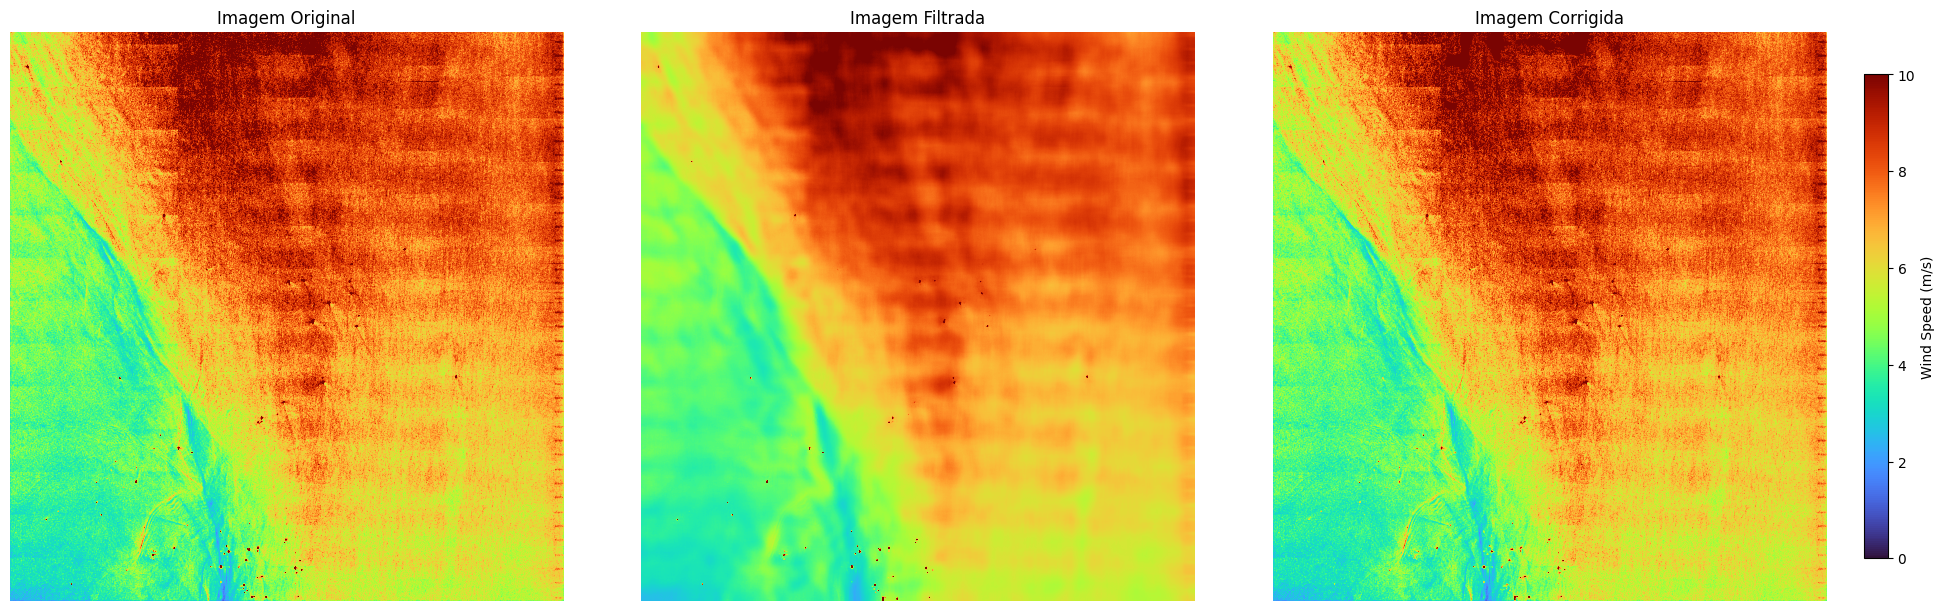

array([[4.87349415, 5.46987963, 6.06626511, ..., 4.07831335, 6.66265059,
        5.86746979],
       [6.66265059, 6.06626511, 7.06024075, ..., 8.45180702, 5.46987963,
        6.26506042],
       [6.06626511, 8.65060234, 6.66265059, ..., 7.6566267 , 7.45783138,
        5.46987963],
       ...,
       [2.09036136, 2.68674707, 2.48795176, ..., 5.27108431, 5.46987963,
        3.87951803],
       [3.08433723, 2.68674707, 3.08433723, ..., 5.27108431, 5.86746979,
        3.48192763],
       [0.89759034, 1.89156628, 1.49397588, ..., 4.47590351, 4.07831335,
        2.68674707]])

In [ ]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np
import os

IMG_PATH = r"C:\Users\peric\Documents\sar2wind_daniel\FROST-FILTER-TEST\input\u10_xmod3.tif"
IMG_FILTERED_PATH = r"C:\Users\peric\Documents\sar2wind_daniel\FROST-FILTER-TEST\output\u10_xmod3_frost.tif"
MASK_PATH = r"C:\Users\peric\Documents\sar2wind_daniel\FROST-FILTER-TEST\output\mask.tif"
IMG_FIX_PATH = r"C:\Users\peric\Documents\sar2wind_daniel\FROST-FILTER-TEST\output\wind_fixed.tif"


def comparar_wind_speed(
    tif_original,
    tif_filtrada,
    tif_mask,
    tif_corrigida,
    titulo1='Imagem Original',
    titulo2='Imagem Filtrada',
    titulo3='Máscara',
    titulo4='Imagem Corrigida',
    cmap='turbo',
    salvar=False,
    nome_saida='comparacao_wind_speed.png'
):

    def ler_tif(caminho):
        with rasterio.open(caminho) as src:
            img = src.read(1)

            if src.nodata is not None:
                img = np.where(img == src.nodata, np.nan, img)

        return img

    # ----- Leitura -----
    img_original = ler_tif(tif_original)
    img_filtrada = ler_tif(tif_filtrada)
    img_mask = ler_tif(tif_mask)
    img_corrigida = ler_tif(tif_corrigida)

    # ----- Figura -----
    fig, axes = plt.subplots(
        2,
        2,
        figsize=(14, 12),
        constrained_layout=True
    )

    # ----- Original -----
    im = axes[0, 0].imshow(
        img_original,
        cmap=cmap,
        vmin=0,
        vmax=10
    )

    axes[0, 0].set_title(titulo1)
    axes[0, 0].axis('off')

    # ----- Filtrada -----
    axes[0, 1].imshow(
        img_filtrada,
        cmap=cmap,
        vmin=0,
        vmax=10
    )

    axes[0, 1].set_title(titulo2)
    axes[0, 1].axis('off')

    # ----- Máscara -----
    axes[1, 0].imshow(
        img_mask,
        cmap=cmap,
        vmin=0,
        vmax=10
    )

    axes[1, 0].set_title(titulo3)
    axes[1, 0].axis('off')

    # ----- Corrigida -----
    axes[1, 1].imshow(
        img_corrigida,
        cmap=cmap,
        vmin=0,
        vmax=10
    )

    axes[1, 1].set_title(titulo4)
    axes[1, 1].axis('off')

    # ----- Colorbar única -----
    cbar = fig.colorbar(
        im,
        ax=axes,
        shrink=0.85,
        pad=0.02
    )

    cbar.set_label('Wind Speed (m/s)')

    # ----- Salvar -----
    if salvar:

        pasta = os.path.dirname(nome_saida)

        if pasta:
            os.makedirs(pasta, exist_ok=True)

        fig.savefig(
            nome_saida,
            dpi=300,
            bbox_inches='tight'
        )

        print(f'Figura salva em:\n{os.path.abspath(nome_saida)}')

    plt.show()

    comparar_wind_speed(
    tif_original=IMG_PATH,
    tif_filtrada=IMG_FILTERED_PATH,
    tif_mask=MASK_PATH,
    tif_corrigida=IMG_FIX_PATH,
    salvar=True,
    nome_saida=r"C:\...\quicklook.png"
)